<a href="https://colab.research.google.com/github/JoaoMAraujoJr/Resolu-es-Atividades-Aprendizado-de-Maquina-Supervisionado/blob/main/Exerccios_da_Unidade_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercícios de Clustering

## K-Means

### Exercício 1: Análise e Seleção de Features

Carregue o dataset `wine` e use a função `seaborn.pairplot` para visualizar as relações entre as features. Analise o gráfico e escolha o par de features que você acredita que melhor separa os 3 grupos. Plote um gráfico de dispersão apenas com o par selecionado.

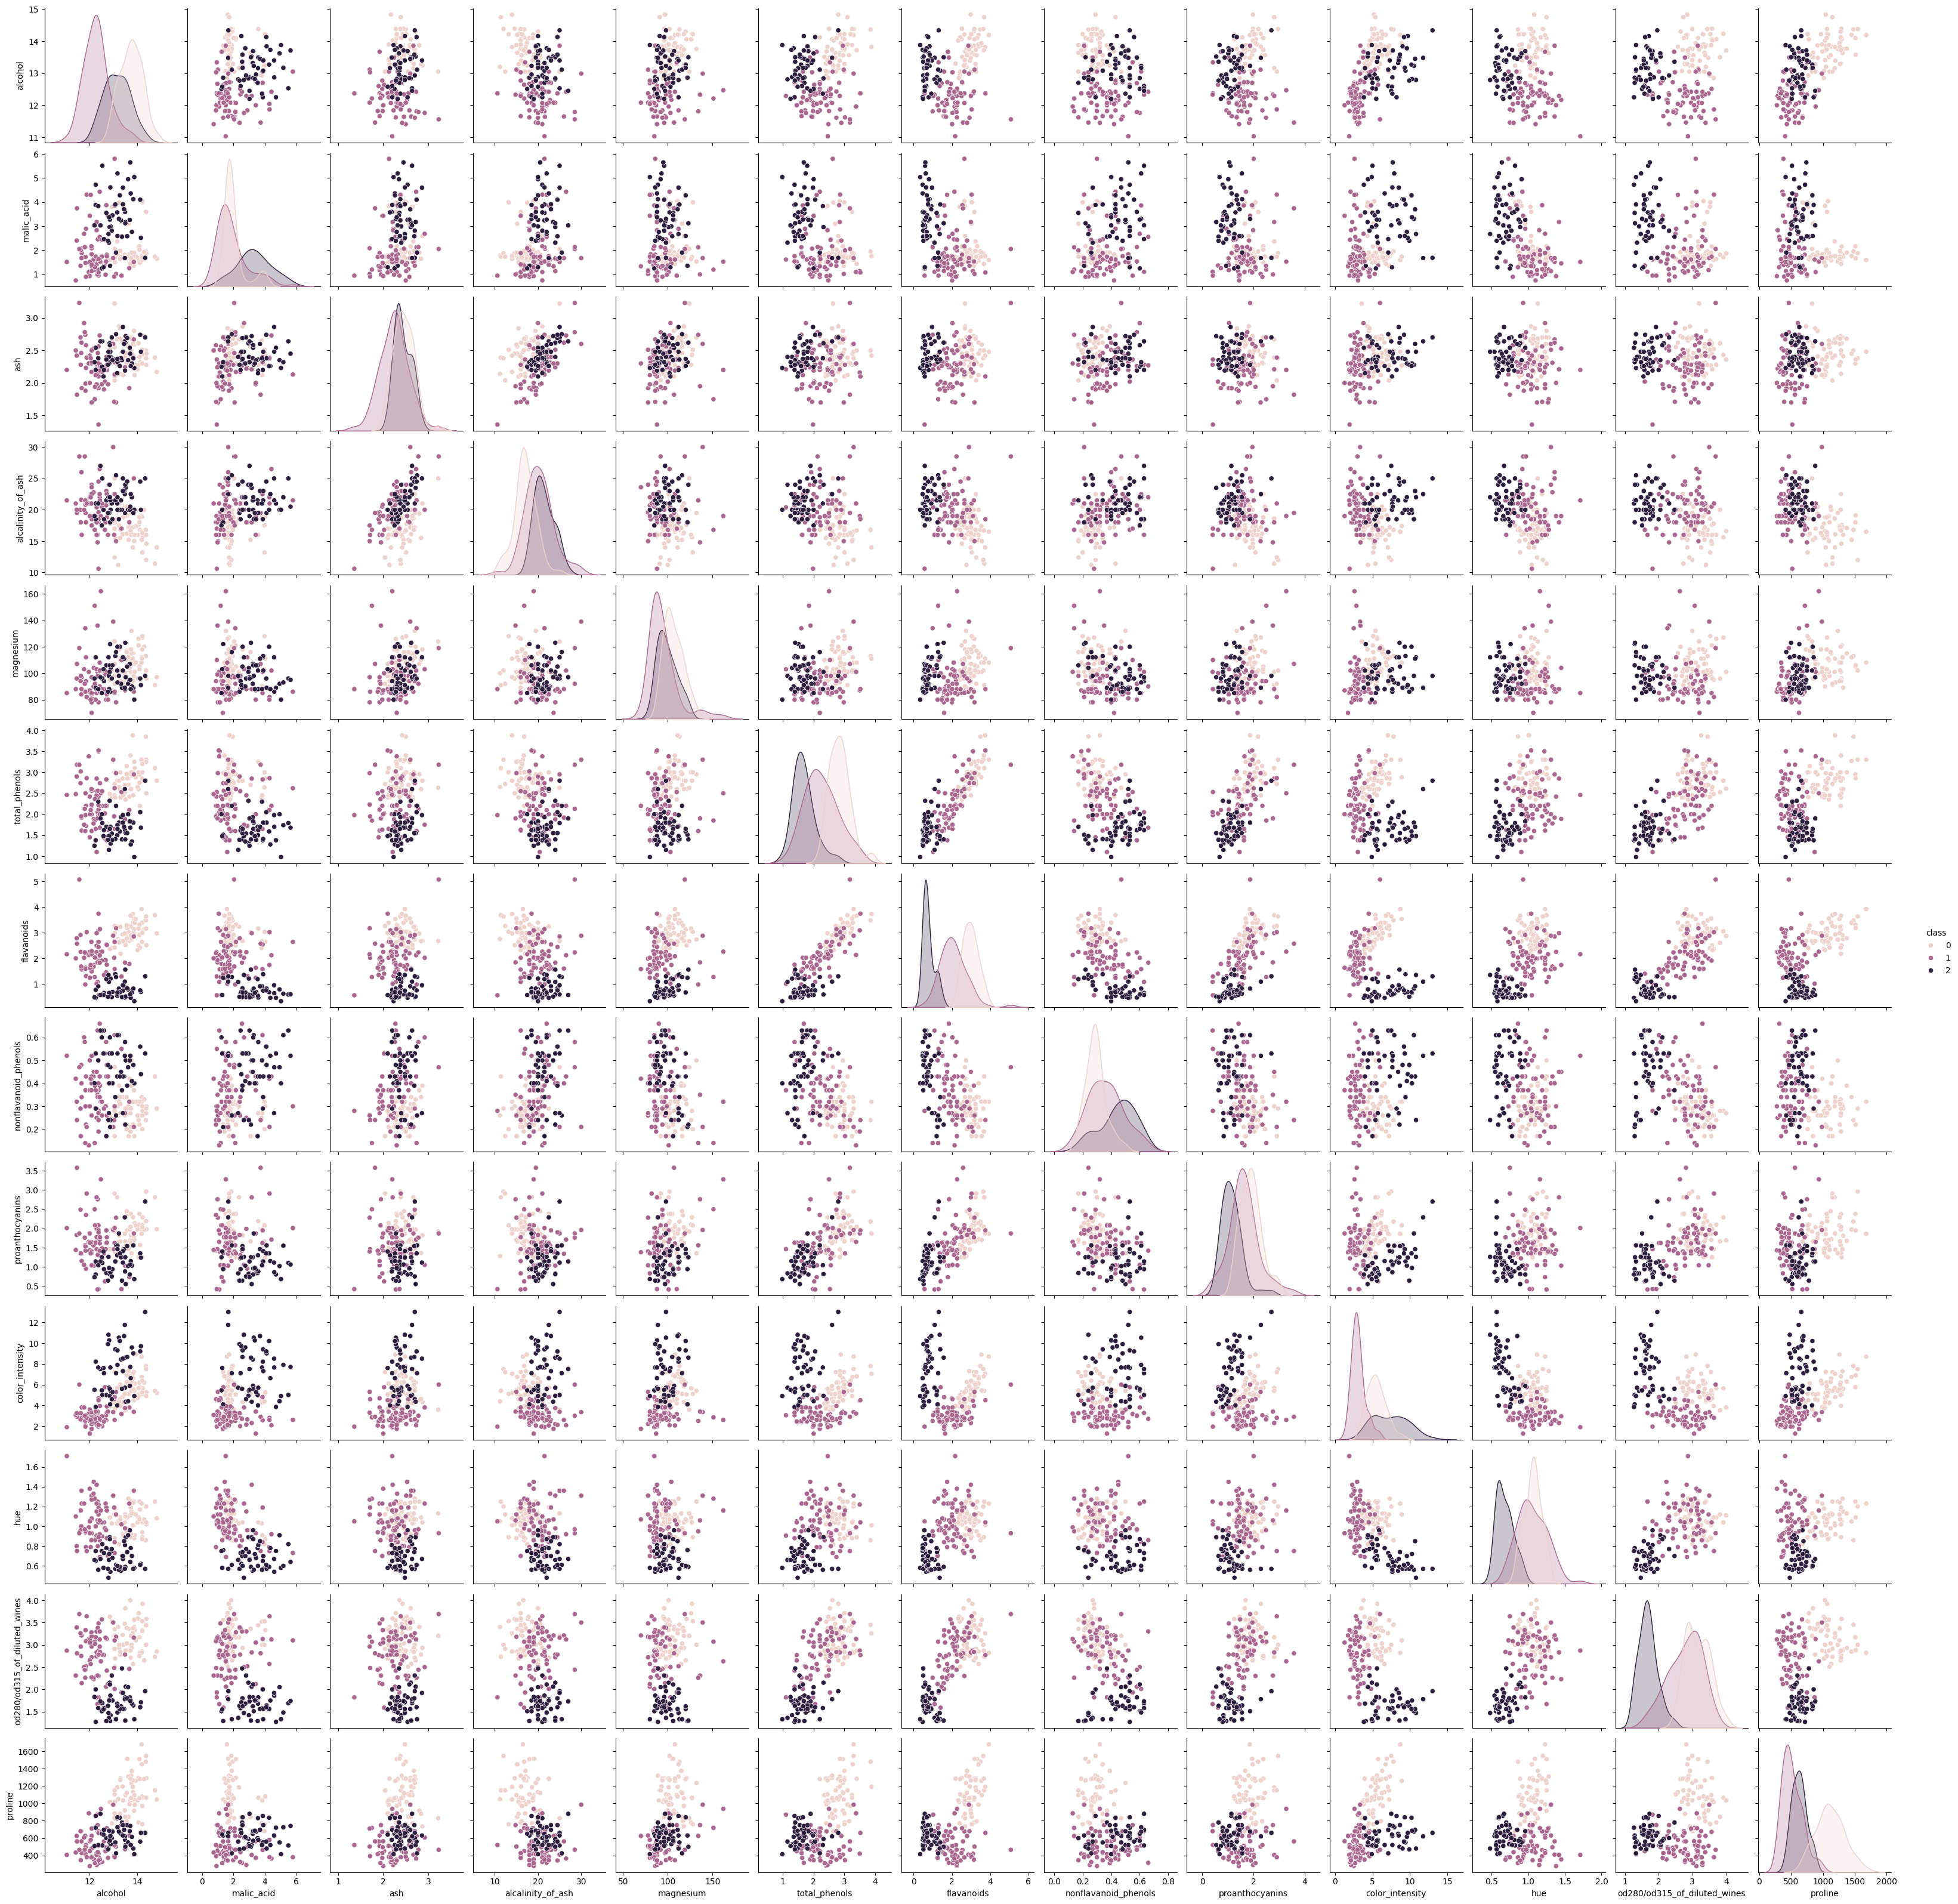

/tmp/ipykernel_1550/4124935366.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


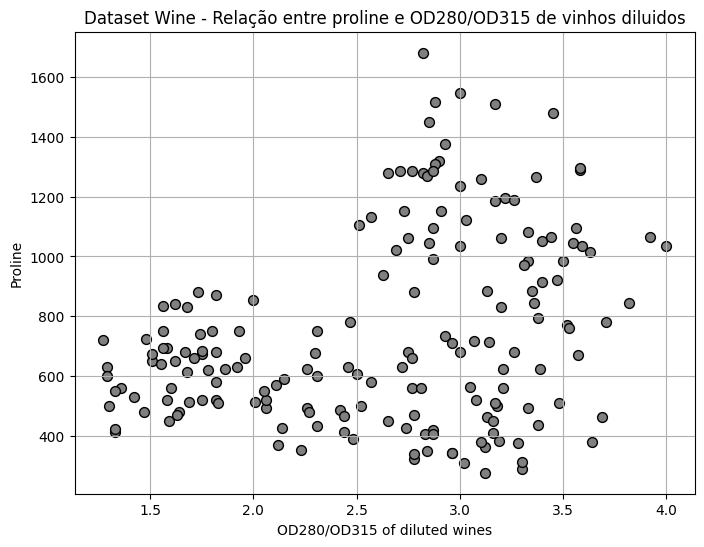

In [6]:
from sklearn.datasets import load_wine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mode

wine = load_wine()
X = wine.data
y_true = wine.target

df = pd.DataFrame(X, columns= wine.feature_names)
df["class"] = y_true

sns.pairplot(df, hue="class")
plt.show()

plt.figure(figsize=(8,6))

plt.scatter(
    df["od280/od315_of_diluted_wines"],
    df["proline"],
    c='gray',
    cmap="viridis",
    edgecolor="k",
    s=50
)

plt.xlabel("OD280/OD315 of diluted wines")
plt.ylabel("Proline")
plt.title("Dataset Wine - Relação entre proline e OD280/OD315 de vinhos diluidos")

plt.grid(True)
plt.show()

### Exercício 2: Encontrando o K Ótimo

Aplique o Método do Cotovelo nas duas features que você escolheu. Calcule e plote a inércia (WCSS) para K de 1 a 10. Com base no seu gráfico, qual parece ser o número ideal de clusters?

In [7]:
class KMeans:
    def __init__(self, n_clusters=3, max_iter=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None
        self.labels = None

    def _initialize_centroids(self, X):
        """
        Inicializa os centróides selecionando K pontos aleatórios do dataset.
        """
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        random_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_indices]

    def _assign_clusters(self, X):
        """
        Atribui cada ponto de dado ao centróide mais próximo.
        """
        n_samples = X.shape[0]
        distances = np.zeros((n_samples, self.n_clusters))

        for i, centroid in enumerate(self.centroids):
            distances[:, i] = np.sum((X - centroid)**2, axis=1)

        self.labels = np.argmin(distances, axis=1)

    def _update_centroids(self, X):
        """
        Atualiza a posição de cada centróide com base na média dos pontos atribuídos a ele.
        """
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))

        for i in range(self.n_clusters):
            cluster_points = X[self.labels == i]
            if len(cluster_points) > 0:
                new_centroids[i] = np.mean(cluster_points, axis=0)
            else:
                new_centroids[i] = self.centroids[i]

        self.centroids = new_centroids

    def fit(self, X):
        """
        Executa o algoritmo K-Means.
        """
        self._initialize_centroids(X)

        for _ in range(self.max_iter):
            old_centroids = self.centroids.copy()
            self._assign_clusters(X)
            self._update_centroids(X)
            if np.allclose(old_centroids, self.centroids):
                break

    def predict(self, X):
        """
        Atribui clusters para novos dados com base nos centróides aprendidos.
        """
        distances = np.zeros((X.shape[0], self.n_clusters))
        for i, centroid in enumerate(self.centroids):
            distances[:, i] = np.sum((X - centroid)**2, axis=1)

        return np.argmin(distances, axis=1)

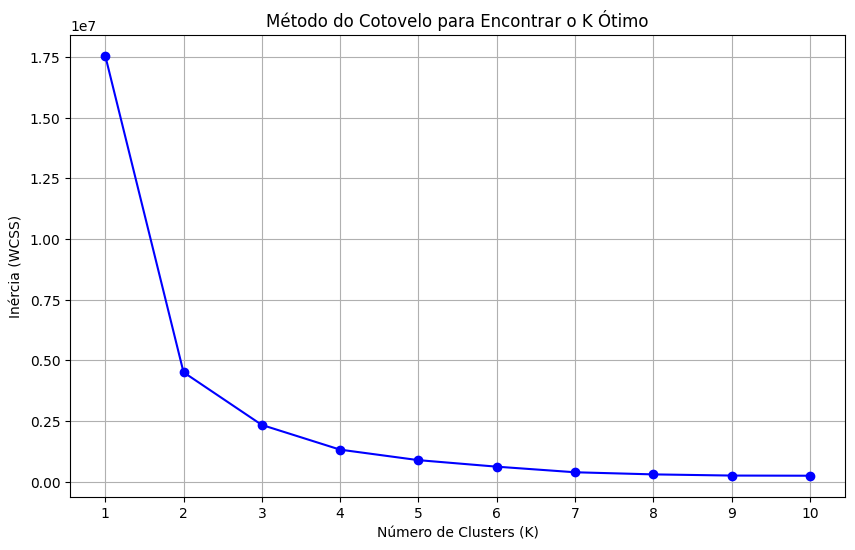

In [8]:
k_range = range(1, 11)
inertias = []
clustering_results = []

X_wine = df[["od280/od315_of_diluted_wines", "proline"]].values
for k in k_range:
    model = KMeans(n_clusters=k, max_iter=150, random_state=42)
    model.fit(X_wine)

    # Calcular a inércia (WCSS)
    current_inertia = 0
    for i in range(k):
        # Seleciona os pontos pertencentes ao cluster i
        cluster_points = X_wine[model.labels == i]
        # Calcula a soma das distâncias quadradas ao centróide do cluster i
        current_inertia += np.sum((cluster_points - model.centroids[i])**2)

    inertias.append(current_inertia)
    clustering_results.append({'labels': model.labels, 'centroids': model.centroids})

# Plotar o gráfico do cotovelo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo para Encontrar o K Ótimo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### Exercício 3: Clusterização e Avaliação

Use o K encontrado na tarefa anterior para treinar seu modelo `KMeans`. Crie um gráfico com dois subplots: um mostrando os clusters encontrados pelo algoritmo e outro mostrando os dados com os rótulos reais para comparação. Por fim, calcule a taxa de acertos e comente o resultado.

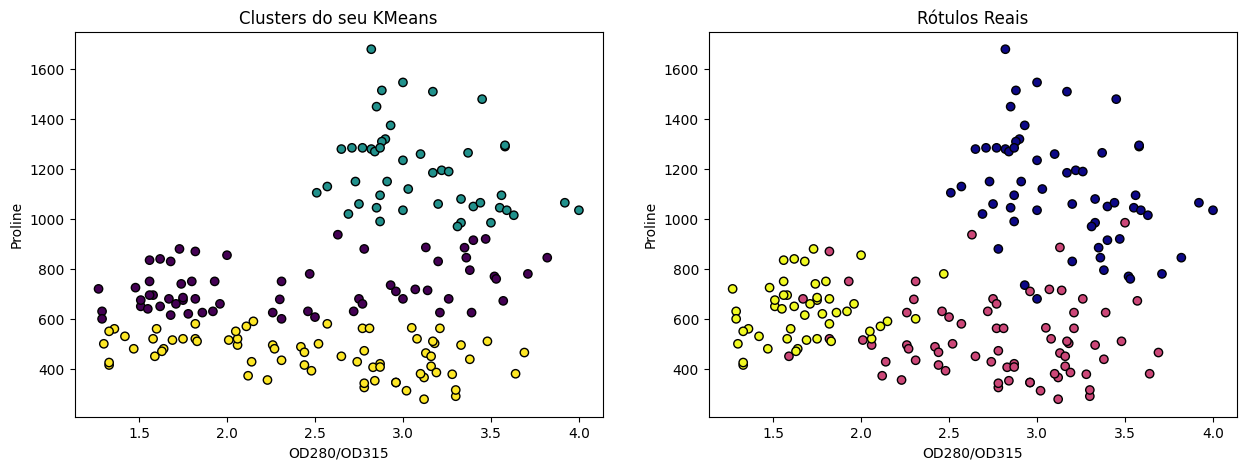

Número de acertos: 125 de 178 pontos.
Taxa de acerto: 70.22%


In [10]:
model = KMeans(n_clusters=3, max_iter=150, random_state=42)
model.fit(X_wine)
y_pred = model.predict(X_wine)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Modelo
scatter1 = ax1.scatter(X_wine[:, 0], X_wine[:, 1], c=y_pred, cmap='viridis', edgecolor='k')
ax1.set_title("Clusters do seu KMeans")
ax1.set_xlabel("OD280/OD315")
ax1.set_ylabel("Proline")

# Reais
scatter2 = ax2.scatter(X_wine[:, 0], X_wine[:, 1], c=y_true, cmap='plasma', edgecolor='k')
ax2.set_title("Rótulos Reais")
ax2.set_xlabel("OD280/OD315")
ax2.set_ylabel("Proline")

plt.show()

correct_predictions = 0
n_samples = X_wine.shape[0]

for i in range(model.n_clusters):
    mask = (y_pred == i)
    dominant_label = mode(y_true[mask], keepdims=True)[0][0]
    hits = np.sum(y_true[mask] == dominant_label)
    correct_predictions += hits

print(f"Número de acertos: {correct_predictions} de {n_samples} pontos.")
print(f"Taxa de acerto: {(correct_predictions / n_samples):.2%}")

## Hierarchical

### Exercício 1: Implementação do Average Linkage

Complete a implementação da nossa classe `HierarchicalClustering` adicionando os métodos **Average Linkage** e **Ward Linkage**. Em seguida, teste todos os quatro métodos de ligação (single, complete, average, ward) no dataset simples (`X_simple`) e compare os resultados.

In [11]:
class HierarchicalClustering:
    def __init__(self, linkage='single'):
        """
        Inicializa o algoritmo de clusterização hierárquica.
        """
        self.linkage = linkage
        self.merge_history = []
        self.distances = []

    def _calculate_distance_matrix(self, X):
        """
        Calcula a matriz de distâncias entre todos os pares de pontos.
        """
        n = len(X)
        dist_matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(i+1, n):
                dist = np.linalg.norm(X[i] - X[j])
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist

        # Para mais performance, use:
        # diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
        # dist_matrix = np.linalg.norm(diff, axis=-1)

        return dist_matrix

    def _cluster_distance(self, cluster1, cluster2, X, dist_matrix):
        """
        Calcula a distância entre dois clusters baseado no critério de ligação.
        """
        if self.linkage == 'single':
            # Distância mínima entre qualquer par de pontos dos clusters
            min_dist = float('inf')
            for i in cluster1:
                for j in cluster2:
                    if dist_matrix[i, j] < min_dist:
                        min_dist = dist_matrix[i, j]
            return min_dist

        elif self.linkage == 'complete':
            # Distância máxima entre qualquer par de pontos dos clusters
            max_dist = 0
            for i in cluster1:
                for j in cluster2:
                    if dist_matrix[i, j] > max_dist:
                        max_dist = dist_matrix[i, j]
            return max_dist

        elif self.linkage == 'average':
          centroid_1 = np.mean(X[cluster1], axis=0)
          centroid_2 = np.mean(X[cluster2], axis=0)
          return np.linalg.norm(centroid_1 - centroid_2)
        else:
            print ("ERRor Metodo não suportado")

    def fit(self, X):
        """
        Executa o algoritmo de clusterização hierárquica aglomerativa.
        """
        n = len(X)

        # Inicializar cada ponto como um cluster
        clusters = [[i] for i in range(n)]

        # Calcular matriz de distâncias inicial
        dist_matrix = self._calculate_distance_matrix(X)

        self.merge_history = []
        self.distances = []

        step = 0
        print(f"Passo inicial: {len(clusters)} clusters individuais")
        print(f"Clusters: {clusters}\n")

        # Continuar até que reste apenas um cluster
        while len(clusters) > 1:
            # Encontrar o par de clusters mais próximo
            min_distance = float('inf')
            merge_i, merge_j = -1, -1

            for i in range(len(clusters)):
              for j in range(i+1, len(clusters)):
                    distance = self._cluster_distance(clusters[i], clusters[j], X, dist_matrix)
                    if distance < min_distance:
                        min_distance = distance
                        merge_i, merge_j = i, j

            # Combinar os clusters mais próximos
            new_cluster = clusters[merge_i] + clusters[merge_j]

            # Salvar informações da fusão
            self.merge_history.append((clusters[merge_i].copy(), clusters[merge_j].copy()))
            self.distances.append(min_distance)

            step += 1
            print(f"Passo {step}: Combinar clusters {clusters[merge_i]} e {clusters[merge_j]}")
            print(f"Distância: {min_distance:.3f}")

            # Remover os clusters antigos e adicionar o novo
            clusters = [clusters[k] for k in range(len(clusters)) if k != merge_i and k != merge_j]
            clusters.append(new_cluster)

            print(f"Clusters restantes: {clusters}\n")

Passo inicial: 6 clusters individuais
Clusters: [[0], [1], [2], [3], [4], [5]]

Passo 1: Combinar clusters [0] e [1]
Distância: 0.539
Clusters restantes: [[2], [3], [4], [5], [0, 1]]

Passo 2: Combinar clusters [4] e [0, 1]
Distância: 1.300
Clusters restantes: [[2], [3], [5], [4, 0, 1]]

Passo 3: Combinar clusters [2] e [3]
Distância: 3.000
Clusters restantes: [[5], [4, 0, 1], [2, 3]]

Passo 4: Combinar clusters [5] e [2, 3]
Distância: 3.162
Clusters restantes: [[4, 0, 1], [5, 2, 3]]

Passo 5: Combinar clusters [4, 0, 1] e [5, 2, 3]
Distância: 7.120
Clusters restantes: [[4, 0, 1, 5, 2, 3]]

Passo inicial: 6 clusters individuais
Clusters: [[0], [1], [2], [3], [4], [5]]

Passo 1: Combinar clusters [0] e [1]
Distância: 0.539
Clusters restantes: [[2], [3], [4], [5], [0, 1]]

Passo 2: Combinar clusters [4] e [0, 1]
Distância: 1.400
Clusters restantes: [[2], [3], [5], [4, 0, 1]]

Passo 3: Combinar clusters [2] e [3]
Distância: 3.000
Clusters restantes: [[5], [4, 0, 1], [2, 3]]

Passo 4: Comb

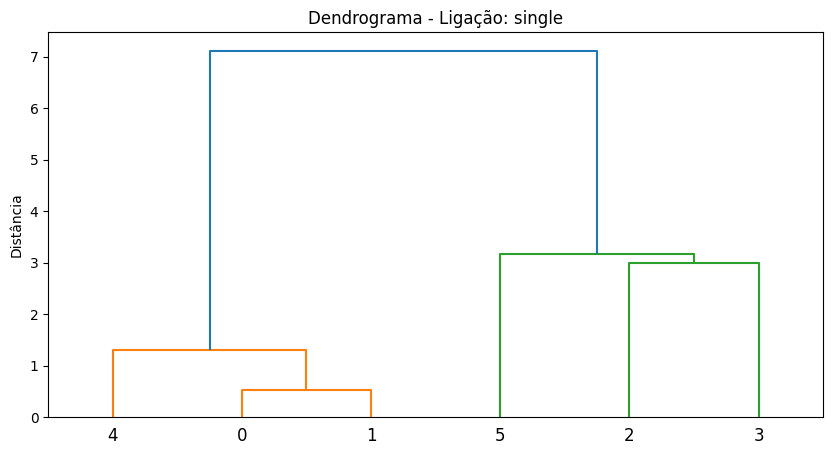

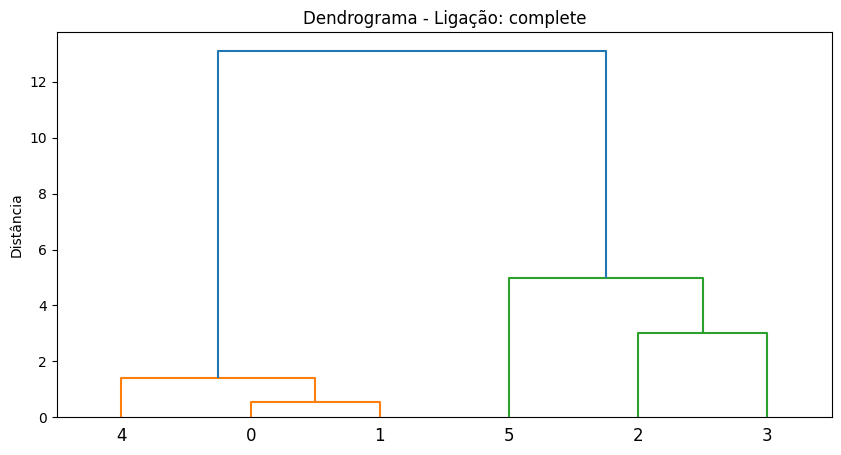

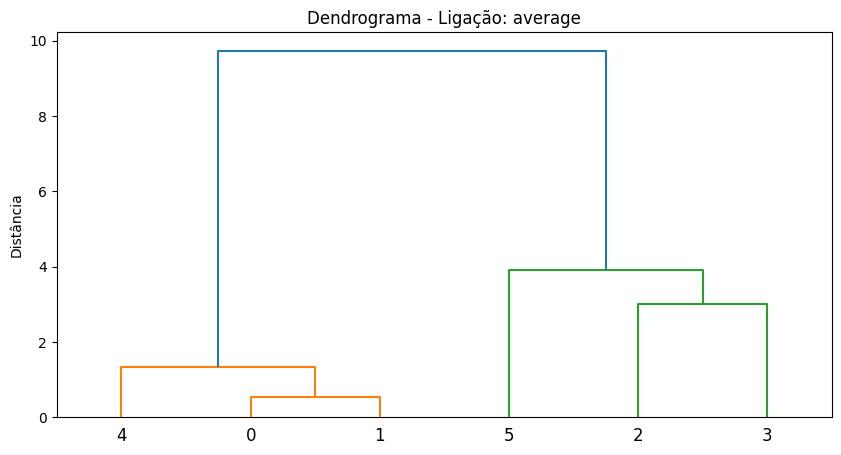

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd
import seaborn as sns

np.random.seed(42)
X_simple = np.array([[1, 2], [1.5, 1.8], [5, 8], [8, 8], [1, 0.6], [9, 11]])

def plot_dendrogram(model, n_samples):
    linkage_matrix = []
    cluster_ids = {tuple([i]): i for i in range(n_samples)}
    current_id = n_samples

    for i in range(len(model.merge_history)):
        cluster_a, cluster_b = model.merge_history[i]
        dist = model.distances[i]

        id_a = cluster_ids[tuple(sorted(cluster_a))]
        id_b = cluster_ids[tuple(sorted(cluster_b))]

        new_cluster = sorted(cluster_a + cluster_b)
        sample_count = len(new_cluster)

        linkage_matrix.append([id_a, id_b, dist, sample_count])
        cluster_ids[tuple(new_cluster)] = current_id
        current_id += 1

    plt.figure(figsize=(10, 5))
    plt.title(f"Dendrograma - Ligação: {model.linkage}")
    dendrogram(np.array(linkage_matrix).astype(float))
    plt.ylabel("Distância")
    plt.show()


single_linkage = HierarchicalClustering(linkage = "single")
full_linkage = HierarchicalClustering(linkage ="complete")
average_linkage = HierarchicalClustering(linkage = "average")

single_linkage.fit(X_simple)
full_linkage.fit(X_simple)
average_linkage.fit(X_simple)


plot_dendrogram(single_linkage, len(X_simple))
plot_dendrogram(full_linkage, len(X_simple))
plot_dendrogram(average_linkage, len(X_simple))


### Exercício 2: Análise do Dataset Wine

Aplique a clusterização hierárquica do SciPy ao dataset Wine. Primeiro, você deve selecionar um bom par de features para visualização bidimensional, depois comparar diferentes métodos de ligação.

Dataset Wine:
Shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']


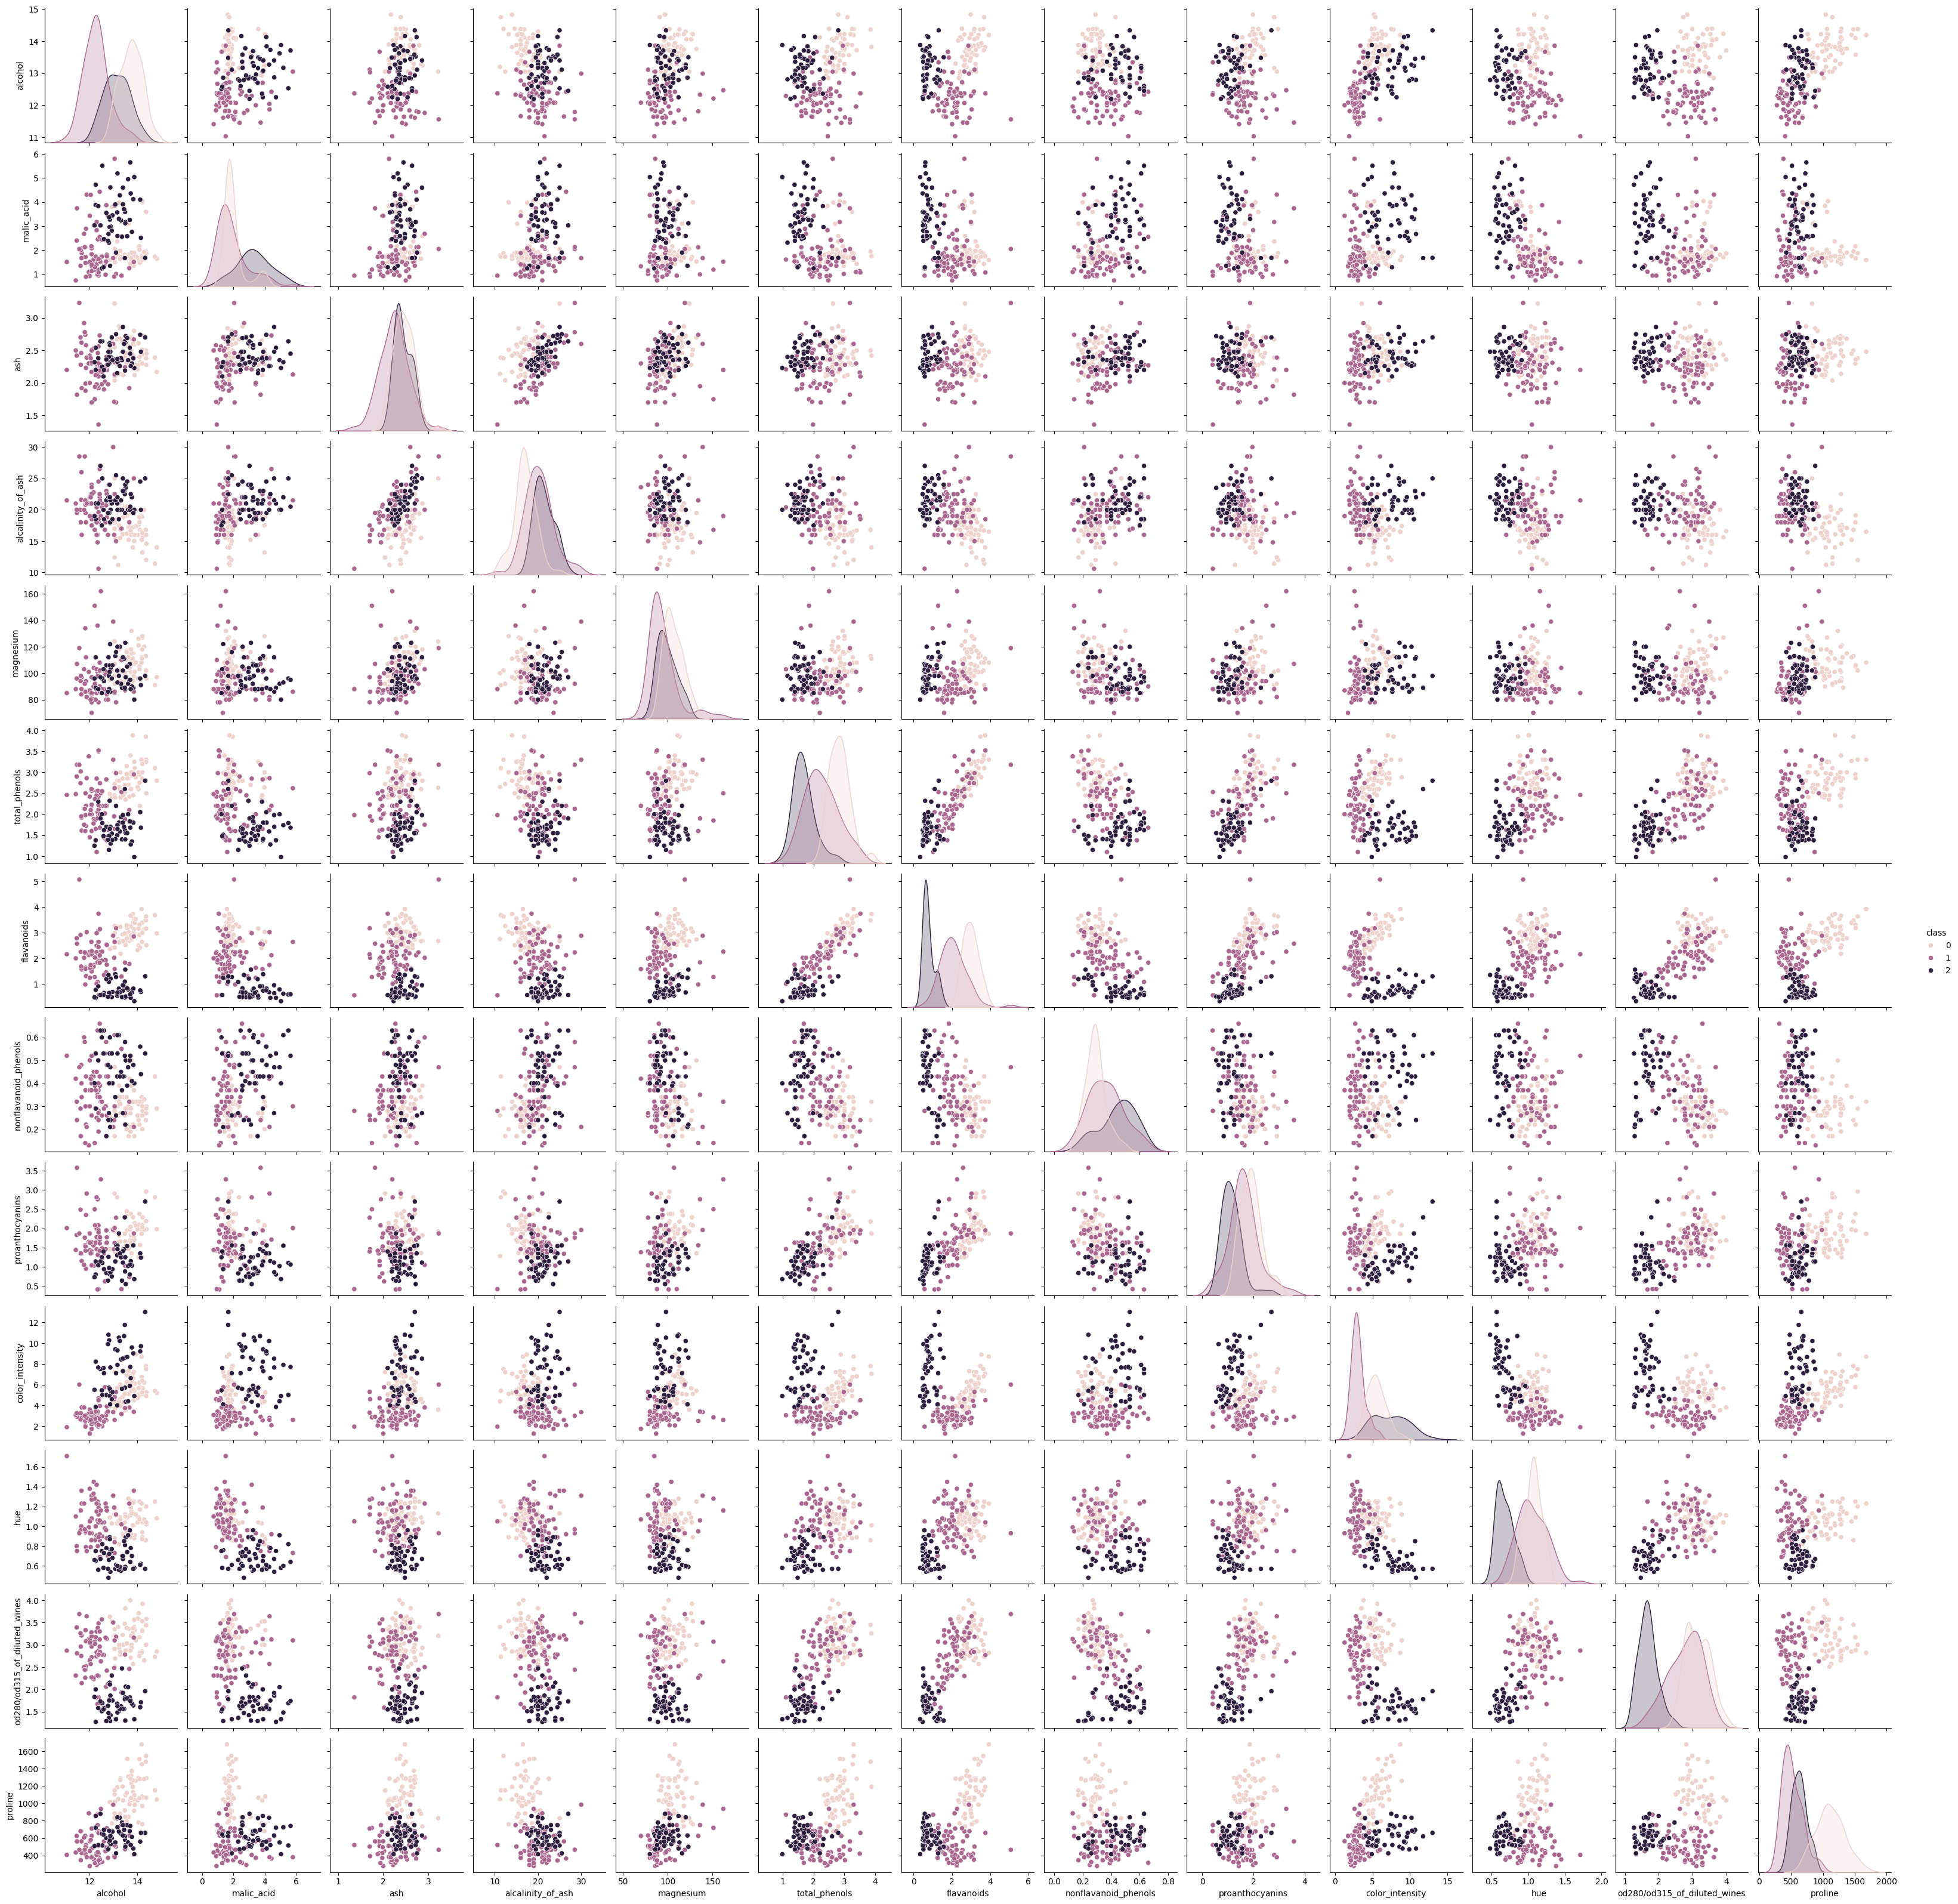

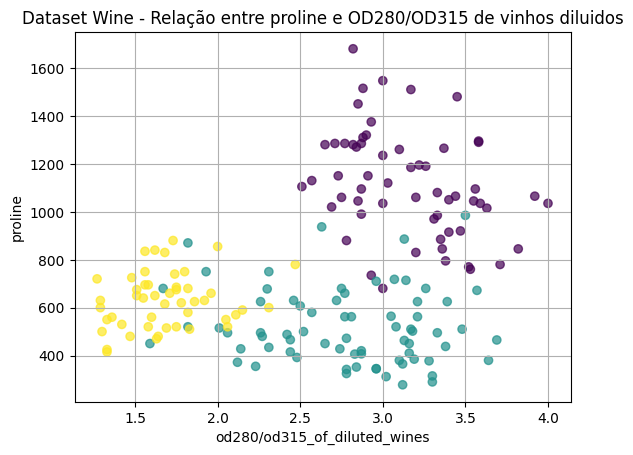

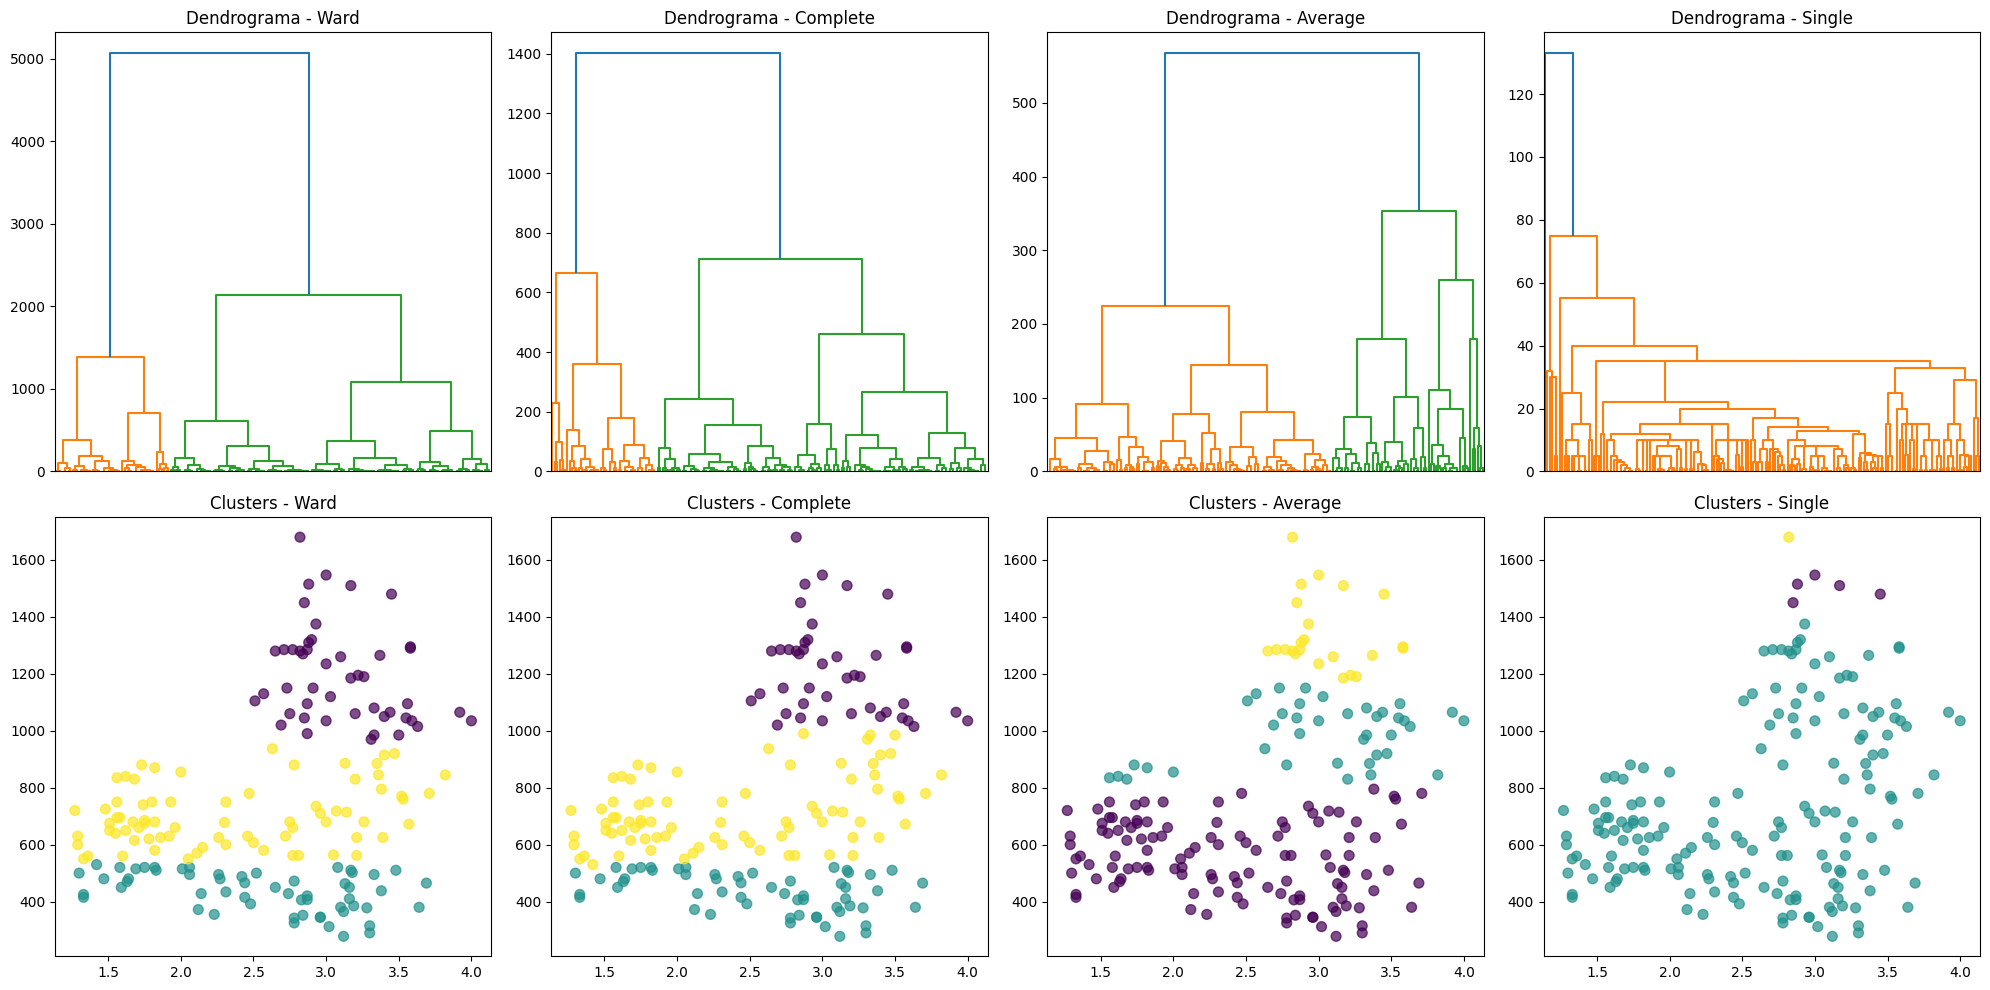

Comparação dos métodos de ligação no dataset Wine:
Ward         Linkage: 71.3% de acertos
Complete     Linkage: 70.2% de acertos
Average      Linkage: 67.4% de acertos
Single       Linkage: 43.3% de acertos


In [13]:
from scipy.cluster.hierarchy import fcluster

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print("Dataset Wine:")
print(f"Shape: {X_wine.shape}")
print(f"Features: {wine.feature_names}")
print(f"Classes: {wine.target_names}")

#1 Análise das features para seleção
df = pd.DataFrame(X_wine, columns= wine.feature_names)
df["class"] = y_wine

sns.pairplot(df, hue="class")
plt.show()

#2 Seleção das duas melhores features
this_X = df[["od280/od315_of_diluted_wines", "proline"]].values

plt.scatter(df["od280/od315_of_diluted_wines"], df["proline"], c=df["class"], alpha=0.7)
plt.xlabel("od280/od315_of_diluted_wines")
plt.ylabel("proline")
plt.title("Dataset Wine - Relação entre proline e OD280/OD315 de vinhos diluidos")

plt.grid(True)
plt.show()

#3 Aplicação dos métodos de ligação e criação dos dendrogramas

methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, method in enumerate(methods):
    #matriz
    linkage_matrix = linkage(this_X, method=method)

    dendrogram(linkage_matrix, ax=axes[0, i], no_labels=True)
    axes[0, i].set_title(f'Dendrograma - {method.capitalize()}')

    # Obter 3 clusters
    clusters = fcluster(linkage_matrix, 3, criterion='maxclust')

    # Plotar os clusters
    scatter = axes[1, i].scatter(this_X[:, 0], this_X[:, 1], c=clusters, s=50, alpha=0.7, cmap='viridis')
    axes[1, i].set_title(f'Clusters - {method.capitalize()}')

plt.tight_layout()
plt.show()

#4 Análise visual e determinação do melhor método
def calculate_purity_wine(y_true, y_pred):
    correct_predictions = 0
    n_samples = len(y_true)

    for cluster_id in np.unique(y_pred):
        mask = (y_pred == cluster_id)
        if np.sum(mask) > 0:
            dominant_label = mode(y_true[mask], keepdims=True)[0][0]
            correct_predictions += np.sum(y_true[mask] == dominant_label)

    return correct_predictions / n_samples

print("Comparação dos métodos de ligação no dataset Wine:")
print("="*50)

for i, method in enumerate(methods):
    linkage_matrix = linkage(this_X, method=method)
    clusters = fcluster(linkage_matrix, 3, criterion='maxclust')
    purity = calculate_purity_wine(y_wine, clusters)
    print(f"{method.capitalize():12} Linkage: {purity:.1%} de acertos")

### Exercício 3: Determinação do Número Ótimo de Clusters

Com base no melhor método de ligação identificado no Exercício 2, determine o número ótimo de clusters para o dataset Wine usando análise visual do dendrograma e validação com os rótulos verdadeiros.

In [ ]:
# Seu código aqui...

## DBSCAN

### Exercício 1: Ajuste de Parâmetros

Utilizando os dados das três esferas concêntricas, construa o gráfico de K-Distance para diferentes valores de `min_pts` a fim de sugerir um intervalo adequado para `eps`, selecione os melhores valores para `min_pts` e `eps`, e, em seguida, visualize em 3D os clusters encontrados com cores distintas, discutindo criticamente como a escolha de `eps` e `min_samples` influenciou a separação das estruturas.

In [ ]:
# Seu código aqui...

### Exercício 2: DBSCAN com Distância Radial

Usando os dados das três esferas concêntricas do exercício anterior, implemente a distância radial e utilize-a no DBSCAN, onde a distância entre dois pontos $x_i$ e $x_j$ é definida como $d_{\mathrm{radial}}(x_i, x_j) = \left| |x_i|_2 - |x_j|_2 \right|$; em seguida, plote o K-Distance radial para sugerir um valor adequado de `eps`, teste diferentes combinações de `eps` e `min_samples`, visualize em 3D os clusters obtidos e compare com o resultado utilizando a distância euclidiana, finalizando com uma análise breve sobre qual configuração apresentou melhor desempenho e por que a métrica radial ajuda nesse tipo de estrutura.

In [ ]:
# Seu código aqui...

### Exercício 3: Detecção de Anomalias com DTW

O **DTW (Dynamic Time Warping)** mede a similaridade entre séries temporais mesmo quando elas estão defasadas no tempo ou evoluem com velocidades diferentes, realizando um alinhamento elástico entre seus pontos. Com isso, padrões semelhantes podem ser reconhecidos mesmo quando não estão perfeitamente sincronizados. Sua matriz de distâncias pode ser calculada, por exemplo, com:

```python
from dtaidistance import dtw

n = len(X)
D = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        dist = dtw.distance_fast(X[i], X[j])
        D[i, j] = D[j, i] = dist
```

Utilize o dataset de senóides com variação e anomalias simuladas para aplicar o DBSCAN com a métrica DTW, experimente diferentes valores de `eps` e `min_samples` até obter uma separação adequada entre séries normais e anômalas, e, ao final, plote todas as séries temporais destacando com uma cor as séries consideradas normais e com outra as séries detectadas como anomalias, isto é, aquelas com `label = -1`.

In [ ]:
# Seu código aqui...

## Clustering Metrics

### Exercício 1: Análise de Escolha de Hiperparâmetros

Altere os parâmetros iniciais dos algoritmos **K-Means**, **Hierárquico Aglomerativo** e **DBSCAN** (por exemplo, variando o número de clusters em `n_clusters` e os valores de `eps` e `min_samples`), execute os modelos nos datasets utilizados anteriormente, avalie os resultados com as métricas **Silhouette Score**, **Davies-Bouldin Index** e **Índice de Dunn**, e analise como as mudanças nos parâmetros influenciam a qualidade dos agrupamentos e o comportamento de cada métrica.

In [ ]:
# Seu código aqui...

### Exercício 2: Avaliando Clustering do Dataset Wine

Aplique os algoritmos de agrupamento **K-Means**, **Hierárquico Aglomerativo** e **DBSCAN** ao conjunto de dados **Iris**, avalie os resultados utilizando as métricas **Silhouette Score**, **Davies-Bouldin Index** e **Índice de Dunn**, compare o desempenho dos métodos com base nessas métricas e discuta qual apresentou melhores resultados considerando as características dos dados e o comportamento de cada algoritmo.

In [ ]:
# Seu código aqui...